# Renderer & Slicer — Visual Exploration
Demonstrates `render_name` and `slice_image` on `'Google'` vs `'G00gle'`.

In [1]:
import sys
sys.path.insert(0, '..')  # make rendering/ importable from notebooks/

import numpy as np
import matplotlib.pyplot as plt
from rendering.renderer import render_name
from rendering.slicer import slice_image

## 1. Rendered images

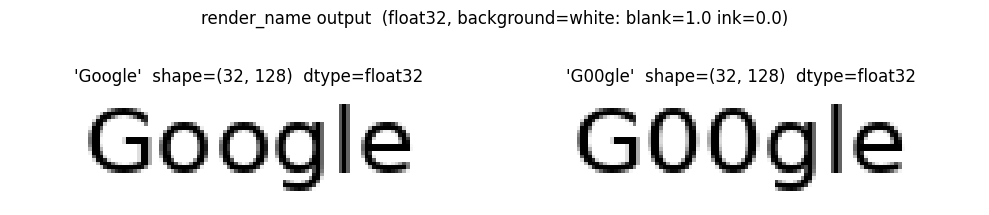

In [2]:
words = ['Google', 'G00gle']
imgs = {w: render_name(w) for w in words}

fig, axes = plt.subplots(1, 2, figsize=(10, 2))
for ax, w in zip(axes, words):
    ax.imshow(imgs[w], cmap='gray', vmin=0, vmax=1,
              aspect='auto', interpolation='nearest')
    ax.set_title(f'{w!r}  shape={imgs[w].shape}  dtype={imgs[w].dtype}')
    ax.axis('off')
plt.suptitle('render_name output  (float32, background=white: blank=1.0 ink=0.0)', y=1.05)
plt.tight_layout()
plt.show()


## 2. Slice heatmaps

Each slice is a `(height, slice_width)` column strip. Slices are shown side-by-side with a narrow separator; index labels are overlaid in the centre of each strip.

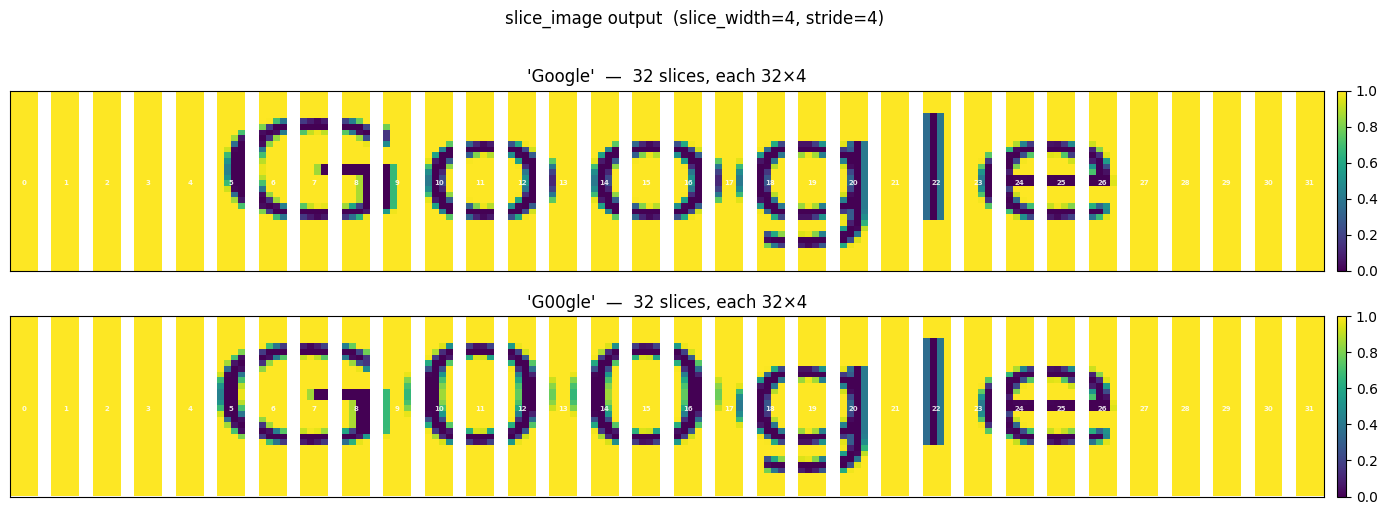

In [3]:
slices = {w: slice_image(imgs[w]) for w in words}

sep = 2  # separator columns between strips

fig, axes = plt.subplots(len(words), 1, figsize=(14, 2 * len(words) + 1), squeeze=False)
axes = axes[:, 0]

for ax, w in zip(axes, words):
    strips = slices[w]           # (n, h, sw)
    n, h, sw = strips.shape

    sep_col = np.full((h, sep), np.nan)
    mosaic = np.concatenate(
        [np.concatenate([strips[i], sep_col], axis=1) for i in range(n)], axis=1
    )[:, :-sep]

    im = ax.imshow(mosaic, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    for i in range(n):
        cx = i * (sw + sep) + (sw - 1) / 2
        ax.text(cx, h / 2, str(i), ha='center', va='center',
                fontsize=5, color='white', fontweight='bold', alpha=0.85)

    ax.set_title(f'{w!r}  —  {n} slices, each {h}×{sw}')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.01, pad=0.01)

plt.suptitle('slice_image output  (slice_width=4, stride=4)', y=1.02)
plt.tight_layout()
plt.show()

## 3. Difference map

Absolute per-slice difference between `'Google'` and `'G00gle'` highlights where the glyphs diverge.

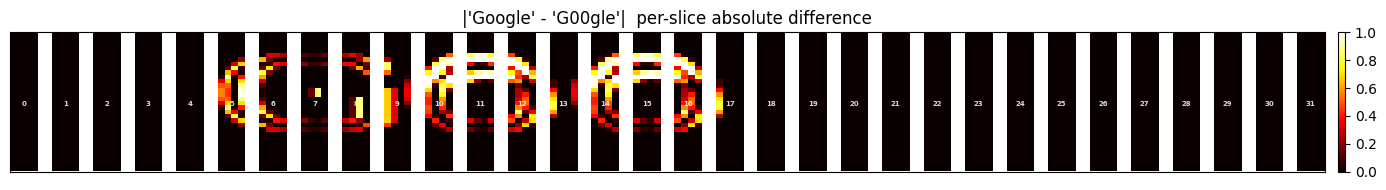

Mean absolute difference: 0.0514
Max  absolute difference: 1.0000


In [4]:
strips_diff = np.abs(slices['Google'] - slices['G00gle'])  # (n, h, sw)
n, h, sw = strips_diff.shape
sep = 2

sep_col = np.full((h, sep), np.nan)
mosaic = np.concatenate(
    [np.concatenate([strips_diff[i], sep_col], axis=1) for i in range(n)], axis=1
)[:, :-sep]

fig, ax = plt.subplots(figsize=(14, 2))
im = ax.imshow(mosaic, cmap='hot', aspect='auto', vmin=0, vmax=1)
for i in range(n):
    cx = i * (sw + sep) + (sw - 1) / 2
    ax.text(cx, h / 2, str(i), ha='center', va='center',
            fontsize=5, color='white', fontweight='bold', alpha=0.85)
ax.set_title("|'Google' - 'G00gle'|  per-slice absolute difference")
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(im, ax=ax, fraction=0.01, pad=0.01)
plt.tight_layout()
plt.show()

diff = strips_diff  # keep name for stats
print(f'Mean absolute difference: {diff.mean():.4f}')
print(f'Max  absolute difference: {diff.max():.4f}')

## 4. Varying height and slice parameters

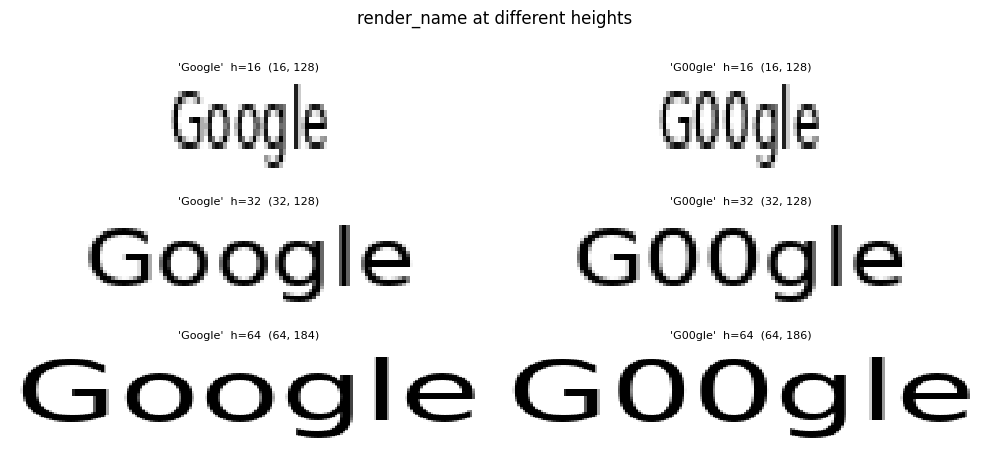

In [5]:
heights = [16, 32, 64]
fig, axes = plt.subplots(len(heights), 2, figsize=(10, len(heights) * 1.5))

for row, h in enumerate(heights):
    for col, w in enumerate(words):
        img = render_name(w, height=h)
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1,
                              aspect='auto', interpolation='nearest')
        axes[row, col].set_title(f'{w!r}  h={h}  {img.shape}', fontsize=8)
        axes[row, col].axis('off')

plt.suptitle('render_name at different heights', y=1.01)
plt.tight_layout()
plt.show()


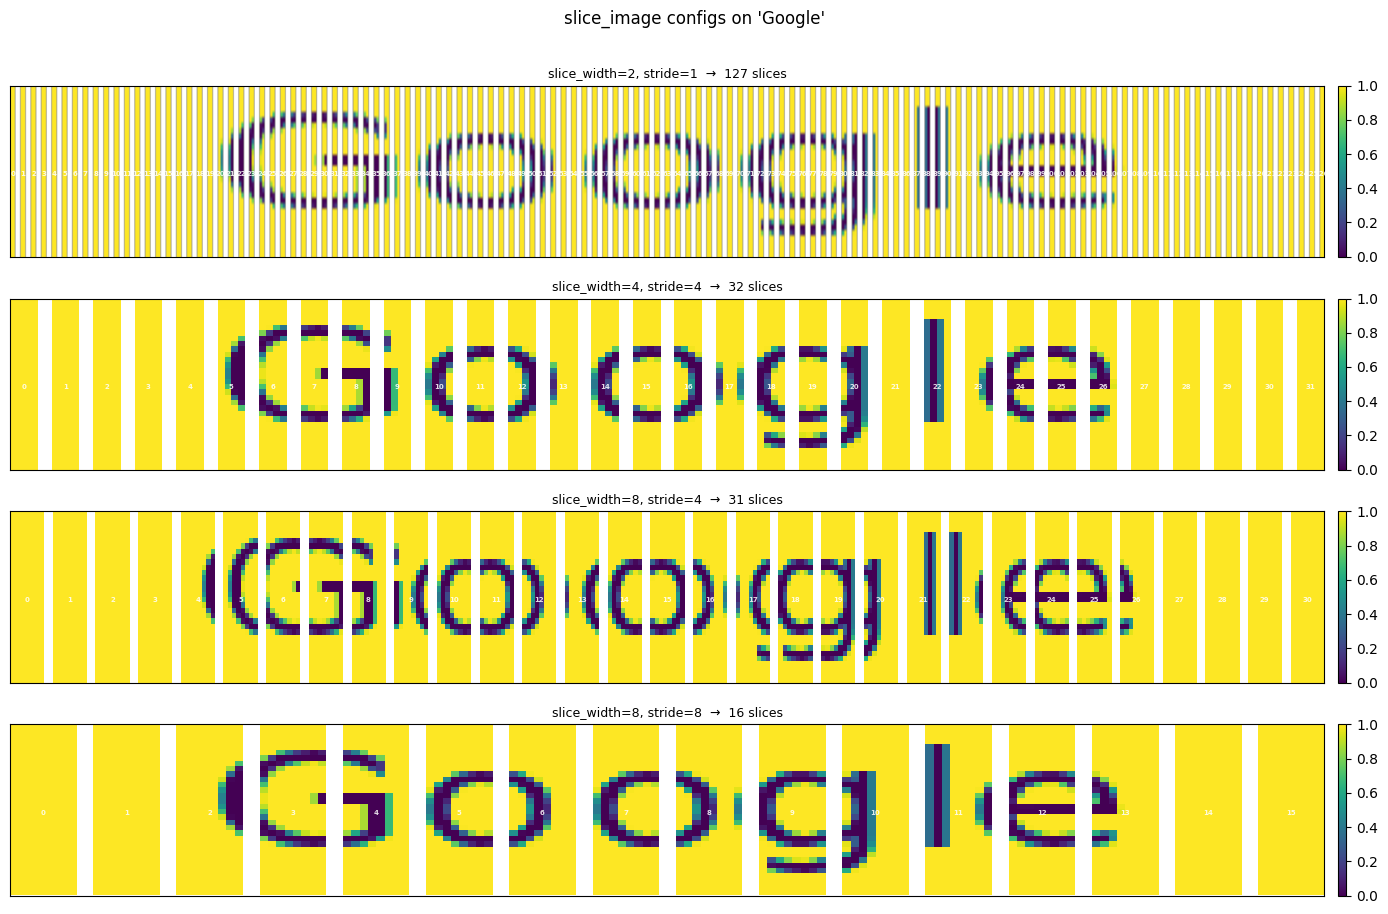

In [6]:
configs = [(2, 1), (4, 4), (8, 4), (8, 8)]
sep = 2
img_google = render_name('Google')

fig, axes = plt.subplots(len(configs), 1, figsize=(14, 2 * len(configs) + 1), squeeze=False)
axes = axes[:, 0]

for ax, (sw, st) in zip(axes, configs):
    strips = slice_image(img_google, slice_width=sw, stride=st)  # (n, h, sw)
    n, h, _ = strips.shape

    sep_col = np.full((h, sep), np.nan)
    mosaic = np.concatenate(
        [np.concatenate([strips[i], sep_col], axis=1) for i in range(n)], axis=1
    )[:, :-sep]

    im = ax.imshow(mosaic, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    for i in range(n):
        cx = i * (sw + sep) + (sw - 1) / 2
        ax.text(cx, h / 2, str(i), ha='center', va='center',
                fontsize=5, color='white', fontweight='bold', alpha=0.85)
    ax.set_title(f'slice_width={sw}, stride={st}  →  {n} slices', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.01, pad=0.01)

plt.suptitle("slice_image configs on 'Google'", y=1.01)
plt.tight_layout()
plt.show()


## 5. Background modes

`render_name` supports `background='white'` (default) and `background='black'`. In both cases blank space = 0.0 and ink = 1.0.

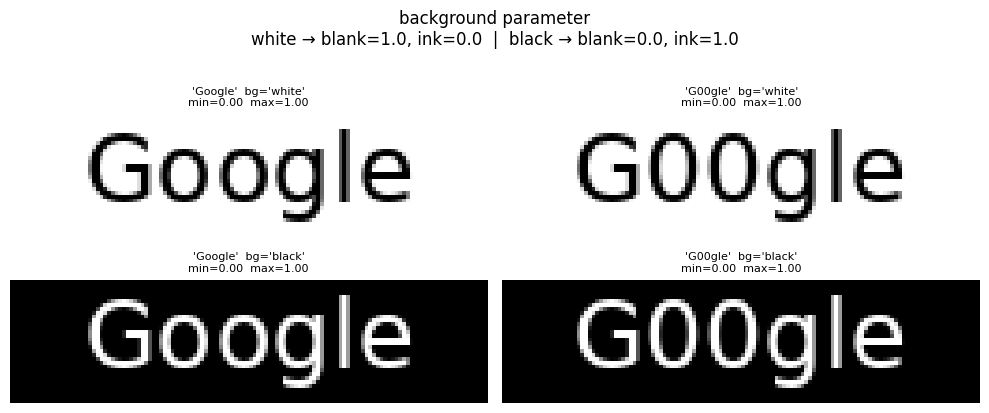

In [7]:
backgrounds = ['white', 'black']

fig, axes = plt.subplots(2, 2, figsize=(10, 4))
for col, w in enumerate(words):
    for row, bg in enumerate(backgrounds):
        img = render_name(w, background=bg)
        ax = axes[row, col]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1,
                  aspect='auto', interpolation='nearest')
        ax.set_title(
            f'{w!r}  bg={bg!r}\nmin={img.min():.2f}  max={img.max():.2f}',
            fontsize=8,
        )
        ax.axis('off')

plt.suptitle(
    "background parameter\n"
    "white → blank=1.0, ink=0.0  |  black → blank=0.0, ink=1.0",
    y=1.02,
)
plt.tight_layout()
plt.show()


# Figures for Paper